<a href="https://colab.research.google.com/github/leonrichandra/bk/blob/main/facilitator_complete_colab_workshop_boyolali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop Data Science: Mengolah Data Menjadi Cerita Bisnis

**Organisasi:** Balik Kampoeng  
**Sekolah:** SMAN 1 Boyolali  
**Tanggal:** 29 Mei 2026  

## Misi workshop
Hari ini kita berperan sebagai **Junior Data Analyst** untuk membantu sebuah usaha susu lokal di Boyolali.
Kita akan mengubah data mentah menjadi laporan bisnis yang rapi, informatif, dan bisa dipresentasikan.

> Catatan: Dataset ini adalah **synthetic dataset** untuk latihan, tetapi dibuat agar dekat dengan konteks Boyolali dan bisnis produk susu.

## 0. Setup library
Kita menggunakan library Python yang umum dipakai dalam data science:

- `pandas` untuk membaca dan mengolah data
- `matplotlib` dan `seaborn` untuk visualisasi
- `plotly` untuk grafik interaktif
- `sklearn` untuk model prediksi sederhana

In [1]:
# Import library yang akan kita pakai
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Supaya angka Rupiah lebih mudah dibaca
def format_rupiah(x):
    return f"Rp{x:,.0f}".replace(',', '.')

pd.set_option('display.max_columns', 50)

## 1. Load dataset

Jika dataset sudah di-upload ke GitHub, ganti nilai `DATA_URL` dengan **Raw GitHub URL**.
Jika belum, upload file `dataset_penjualan_susu_boyolali.csv` ke Colab lalu jalankan cell ini.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/leonrichandra/bk/refs/heads/main/dataset_penjualan_susu_boyolali.csv"
FILE_NAME = "dataset_penjualan_susu_boyolali.csv"

if DATA_URL:
    df_raw = pd.read_csv(DATA_URL)
else:
    df_raw = pd.read_csv(FILE_NAME)

print("Dataset berhasil dibaca!")
df_raw.head()

Dataset berhasil dibaca!


,tanggal,kecamatan,produk,kategori_produk,jenis_pelanggan,channel_penjualan,jumlah_terjual,harga_satuan,total_penjualan,suhu_udara_celsius,musim,hari_libur,promo_aktif,stok_awal,stok_sisa,jarak_pengiriman_km,biaya_distribusi,metode_pembayaran,rating_pelanggan
0,2024-01-01,Cepogo,Keju Mozzarella,Olahan,Toko Modern,Titip Jual,46,29199.0,1343154.0,24.2,Hujan,Ya,Tidak,125,78,16,8318,Tunai,3.4
1,2024-01-01,Musuk,Susu UHT,Susu Cair,Toko Modern,Offline,45,8650.0,389250.0,24.2,Hujan,Ya,Tidak,87,44,18,9626,Tunai,3.8
2,2024-01-01,Mojosongo,Susu Segar,Susu Cair,Warung,Online,53,12116.0,642148.0,24.2,Hujan,Ya,Tidak,94,44,13,6821,Tunai,4.1
3,2024-01-02,Ampel,Es Krim,Snack,Restoran/Kafe,Offline,38,7105.0,269990.0,25.0,Hujan,Tidak,Tidak,65,26,14,6534,Tunai,3.1
4,2024-01-02,Cepogo,Susu UHT,Susu Cair,Restoran/Kafe,Offline,55,8669.0,476795.0,25.0,Hujan,Tidak,Tidak,113,62,16,8151,Tunai,5.0


## 2. Eksplorasi awal: mengenal data mentah

Sebelum analisis, kita harus paham dulu struktur data.
Pertanyaan awal:

1. Ada berapa baris dan kolom?
2. Kolom apa saja yang tersedia?
3. Apakah ada data kosong?
4. Apakah ada data duplikat?

In [4]:
# Melihat ukuran dataset: (jumlah_baris, jumlah_kolom)
df_raw.shape

(2102, 19)

In [5]:
# Melihat daftar kolom dan tipe data
# object biasanya berarti teks, int/float berarti angka
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2102 entries, 0 to 2101
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tanggal              2102 non-null   object 
 1   kecamatan            2102 non-null   object 
 2   produk               2102 non-null   object 
 3   kategori_produk      2102 non-null   object 
 4   jenis_pelanggan      2102 non-null   object 
 5   channel_penjualan    2102 non-null   object 
 6   jumlah_terjual       2102 non-null   int64  
 7   harga_satuan         2072 non-null   float64
 8   total_penjualan      2072 non-null   float64
 9   suhu_udara_celsius   2102 non-null   float64
 10  musim                2102 non-null   object 
 11  hari_libur           2102 non-null   object 
 12  promo_aktif          2102 non-null   object 
 13  stok_awal            2102 non-null   int64  
 14  stok_sisa            2102 non-null   int64  
 15  jarak_pengiriman_km  2102 non-null   i

In [6]:
# Melihat statistik sederhana untuk kolom angka
df_raw.describe()

,jumlah_terjual,harga_satuan,total_penjualan,suhu_udara_celsius,stok_awal,stok_sisa,jarak_pengiriman_km,biaya_distribusi,rating_pelanggan
count,2102.000000,2072.000000,2.072000e+03,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000
mean,48.903425,11106.208494,5.318584e+05,26.658421,95.077545,47.260228,13.703616,7270.982398,4.223549
std,19.610503,6247.713390,3.153152e+05,2.425219,25.901255,18.742356,5.808312,2509.206140,0.433730
min,4.000000,4100.000000,4.991000e+04,19.500000,33.000000,0.000000,2.000000,888.000000,2.800000
25%,36.000000,7282.250000,3.241755e+05,25.000000,77.000000,31.000000,9.000000,5325.500000,3.900000
50%,46.000000,9837.500000,4.505785e+05,26.700000,94.000000,46.500000,15.000000,7585.000000,4.200000
75%,60.000000,11962.250000,7.187138e+05,28.400000,113.000000,64.000000,18.000000,9166.000000,4.500000
max,420.000000,30020.000000,5.040000e+06,34.200000,198.000000,84.000000,27.000000,14252.000000,5.000000


In [7]:
# Mengecek jumlah data kosong di setiap kolom
df_raw.isnull().sum()

,0
tanggal,0
kecamatan,0
produk,0
kategori_produk,0
jenis_pelanggan,0
channel_penjualan,0
jumlah_terjual,0
harga_satuan,30
total_penjualan,30
suhu_udara_celsius,0


In [8]:
# Mengecek jumlah baris duplikat
df_raw.duplicated().sum()

np.int64(1)

## 3. Data cleaning sederhana

Data dunia nyata jarang langsung rapi. Di bagian ini kita akan memperbaiki masalah umum:

- format tanggal
- nama produk yang tidak konsisten
- harga satuan yang kosong
- baris duplikat

In [9]:
# Buat copy agar data mentah tetap aman
df = df_raw.copy()

# 1) Ubah kolom tanggal menjadi format tanggal Python
df['tanggal'] = pd.to_datetime(df['tanggal'])

# 2) Rapikan nama produk: hilangkan spasi, buat format judul
df['produk'] = df['produk'].astype(str).str.strip().str.title()

# Perbaiki beberapa nama produk yang butuh kapitalisasi khusus
df['produk'] = df['produk'].replace({
    'Susu Uht': 'Susu UHT',
    'Susu Segar': 'Susu Segar',
    'Keju Mozzarella': 'Keju Mozzarella',
    'Permen Susu': 'Permen Susu',
    'Es Krim': 'Es Krim'
})

# 3) Isi harga_satuan kosong dengan median harga berdasarkan produk
median_harga_per_produk = df.groupby('produk')['harga_satuan'].transform('median')
df['harga_satuan'] = df['harga_satuan'].fillna(median_harga_per_produk)

# 4) Hitung ulang total_penjualan setelah harga diperbaiki
df['total_penjualan'] = df['jumlah_terjual'] * df['harga_satuan']

# 5) Hapus baris duplikat
df = df.drop_duplicates()

print("Data setelah cleaning:")
print(df.shape)
df.head()

Data setelah cleaning:
(2101, 19)


,tanggal,kecamatan,produk,kategori_produk,jenis_pelanggan,channel_penjualan,jumlah_terjual,harga_satuan,total_penjualan,suhu_udara_celsius,musim,hari_libur,promo_aktif,stok_awal,stok_sisa,jarak_pengiriman_km,biaya_distribusi,metode_pembayaran,rating_pelanggan
0,2024-01-01,Cepogo,Keju Mozzarella,Olahan,Toko Modern,Titip Jual,46,29199.0,1343154.0,24.2,Hujan,Ya,Tidak,125,78,16,8318,Tunai,3.4
1,2024-01-01,Musuk,Susu UHT,Susu Cair,Toko Modern,Offline,45,8650.0,389250.0,24.2,Hujan,Ya,Tidak,87,44,18,9626,Tunai,3.8
2,2024-01-01,Mojosongo,Susu Segar,Susu Cair,Warung,Online,53,12116.0,642148.0,24.2,Hujan,Ya,Tidak,94,44,13,6821,Tunai,4.1
3,2024-01-02,Ampel,Es Krim,Snack,Restoran/Kafe,Offline,38,7105.0,269990.0,25.0,Hujan,Tidak,Tidak,65,26,14,6534,Tunai,3.1
4,2024-01-02,Cepogo,Susu UHT,Susu Cair,Restoran/Kafe,Offline,55,8669.0,476795.0,25.0,Hujan,Tidak,Tidak,113,62,16,8151,Tunai,5.0


In [10]:
# Cek ulang: seharusnya data kosong dan duplikat sudah berkurang/hilang
print("Missing values:")
print(df.isnull().sum())
print("\nJumlah duplikat:", df.duplicated().sum())

Missing values:
tanggal                0
kecamatan              0
produk                 0
kategori_produk        0
jenis_pelanggan        0
channel_penjualan      0
jumlah_terjual         0
harga_satuan           0
total_penjualan        0
suhu_udara_celsius     0
musim                  0
hari_libur             0
promo_aktif            0
stok_awal              0
stok_sisa              0
jarak_pengiriman_km    0
biaya_distribusi       0
metode_pembayaran      0
rating_pelanggan       0
dtype: int64

Jumlah duplikat: 0


## 4. Feature engineering: membuat kolom baru

Feature engineering artinya membuat kolom baru yang membantu analisis.
Di sini kita buat kolom bulan, hari dalam minggu, dan flag angka untuk promo/libur.

In [11]:
df['bulan'] = df['tanggal'].dt.to_period('M').astype(str)
df['nama_hari'] = df['tanggal'].dt.day_name()
df['akhir_pekan'] = df['tanggal'].dt.weekday >= 5

# Buat flag angka agar bisa dipakai untuk correlation dan model prediksi
df['promo_flag'] = (df['promo_aktif'] == 'Ya').astype(int)
df['hari_libur_flag'] = (df['hari_libur'] == 'Ya').astype(int)

df[['tanggal', 'bulan', 'nama_hari', 'akhir_pekan', 'promo_flag', 'hari_libur_flag']].head()

,tanggal,bulan,nama_hari,akhir_pekan,promo_flag,hari_libur_flag
0,2024-01-01,2024-01,Monday,False,0,1
1,2024-01-01,2024-01,Monday,False,0,1
2,2024-01-01,2024-01,Monday,False,0,1
3,2024-01-02,2024-01,Tuesday,False,0,0
4,2024-01-02,2024-01,Tuesday,False,0,0


## 5. Analisis bisnis: menjawab pertanyaan Pak Bambang

Sekarang kita mulai menjawab pertanyaan bisnis:

1. Produk apa yang menghasilkan penjualan terbesar?
2. Kecamatan mana yang paling kuat?
3. Apakah promo benar-benar membantu?
4. Apakah ada pola khusus saat hari libur?

In [12]:
# Total penjualan dan jumlah terjual berdasarkan produk
analisis_produk = (
    df.groupby('produk')
      .agg(total_qty=('jumlah_terjual', 'sum'),
           total_penjualan=('total_penjualan', 'sum'),
           rata_rata_harga=('harga_satuan', 'mean'))
      .sort_values('total_penjualan', ascending=False)
)

analisis_produk['total_penjualan_rp'] = analisis_produk['total_penjualan'].apply(format_rupiah)
analisis_produk

,total_qty,total_penjualan,rata_rata_harga,total_penjualan_rp
produk,,,,
Susu Segar,38722,458436502.5,11874.702401,Rp458.436.502
Keju Mozzarella,7871,216484569.0,27589.066524,Rp216.484.569
Yogurt,16032,157822258.0,9874.601671,Rp157.822.258
Susu UHT,17307,144743130.0,8392.627204,Rp144.743.130
Es Krim,14734,101811525.0,6938.977860,Rp101.811.525
Permen Susu,8073,39728000.0,4942.379845,Rp39.728.000


In [13]:
# Analisis kecamatan: siapa pasar terbesar?
analisis_kecamatan = (
    df.groupby('kecamatan')
      .agg(total_qty=('jumlah_terjual', 'sum'),
           total_penjualan=('total_penjualan', 'sum'),
           rata_rating=('rating_pelanggan', 'mean'))
      .sort_values('total_penjualan', ascending=False)
)
analisis_kecamatan['total_penjualan_rp'] = analisis_kecamatan['total_penjualan'].apply(format_rupiah)
analisis_kecamatan

,total_qty,total_penjualan,rata_rating,total_penjualan_rp
kecamatan,,,,
Cepogo,21612,231999191.5,4.234217,Rp231.999.192
Ampel,18034,199405678.5,4.218667,Rp199.405.678
Mojosongo,17075,193124228.0,4.209915,Rp193.124.228
Musuk,17531,182535618.0,4.248518,Rp182.535.618
Boyolali Kota,15219,165397820.5,4.210476,Rp165.397.820
Selo,13268,146563448.0,4.212868,Rp146.563.448


In [14]:
# Multi-level groupby: penjualan per kecamatan dan produk
pivot_kecamatan_produk = pd.pivot_table(
    df,
    index='kecamatan',
    columns='produk',
    values='jumlah_terjual',
    aggfunc='sum',
    fill_value=0
)

pivot_kecamatan_produk

produk,Es Krim,Keju Mozzarella,Permen Susu,Susu Segar,Susu UHT,Yogurt
kecamatan,,,,,,
Ampel,2715,1560,1574,6911,2742,2532
Boyolali Kota,2380,1246,1199,5394,2579,2421
Cepogo,2924,1363,1395,7837,3774,4319
Mojosongo,2610,1711,1350,6548,2582,2274
Musuk,2455,996,1647,6567,3327,2539
Selo,1650,995,908,5465,2303,1947


In [15]:
# Dampak promo berdasarkan jenis pelanggan
promo_effect = (
    df.groupby(['jenis_pelanggan', 'promo_aktif'])
      .agg(rata_qty=('jumlah_terjual', 'mean'),
           total_penjualan=('total_penjualan', 'sum'),
           jumlah_transaksi=('jumlah_terjual', 'count'))
      .reset_index()
)

promo_effect

,jenis_pelanggan,promo_aktif,rata_qty,total_penjualan,jumlah_transaksi
0,Pasar Tradisional,Tidak,46.955224,248133395.5,469
1,Pasar Tradisional,Ya,48.386364,22244871.5,44
2,Restoran/Kafe,Tidak,50.224422,170103750.0,303
3,Restoran/Kafe,Ya,54.842105,21398286.0,38
4,Toko Modern,Tidak,48.010309,205952992.0,388
5,Toko Modern,Ya,65.811111,54893670.0,90
6,Warung,Tidak,47.171223,356983209.5,695
7,Warung,Ya,53.391892,39315810.0,74


## 6. Visualisasi: membuat data lebih mudah dipahami

Visualisasi membantu kita melihat pola dengan cepat.

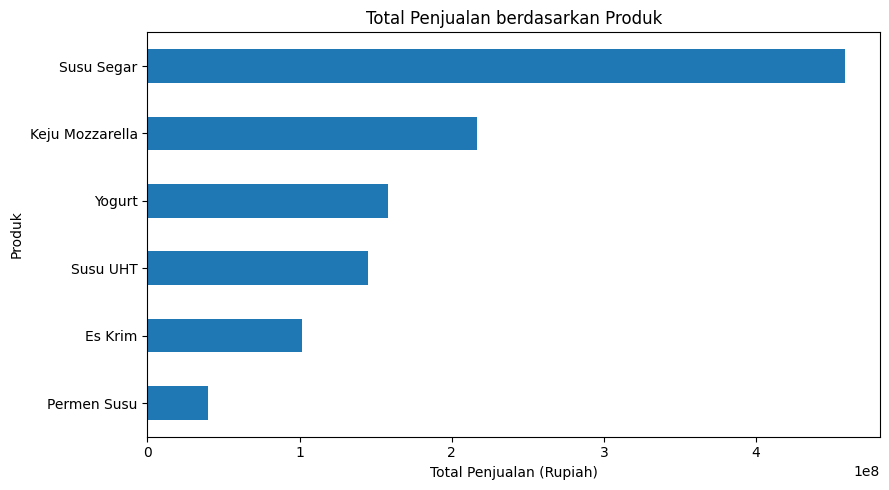

In [16]:
# Visualisasi 1: total penjualan per produk
plt.figure(figsize=(9,5))
analisis_produk['total_penjualan'].sort_values().plot(kind='barh')
plt.title('Total Penjualan berdasarkan Produk')
plt.xlabel('Total Penjualan (Rupiah)')
plt.ylabel('Produk')
plt.tight_layout()
plt.show()

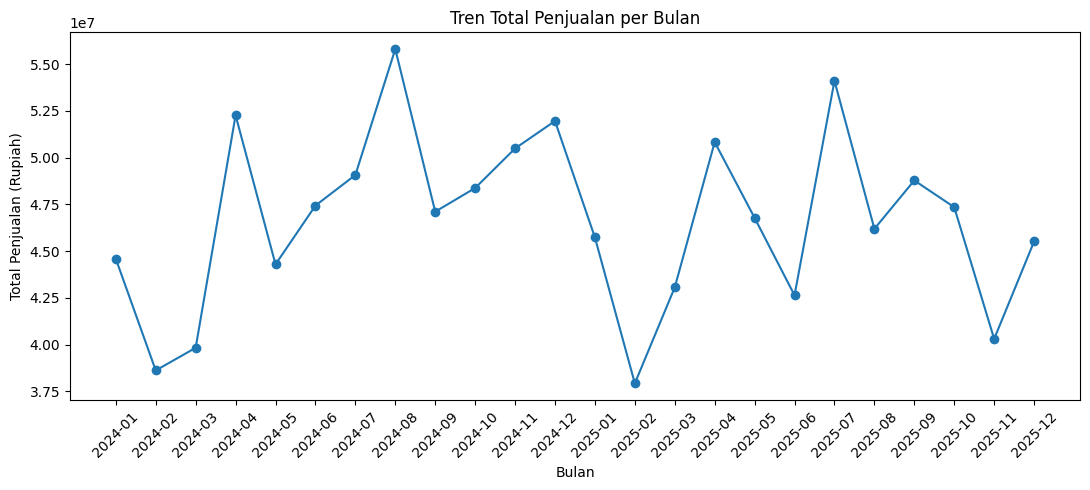

In [17]:
# Visualisasi 2: tren penjualan bulanan
tren_bulanan = df.groupby('bulan')['total_penjualan'].sum().reset_index()

plt.figure(figsize=(11,5))
plt.plot(tren_bulanan['bulan'], tren_bulanan['total_penjualan'], marker='o')
plt.title('Tren Total Penjualan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Total Penjualan (Rupiah)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# Visualisasi 3: grafik interaktif dengan Plotly
fig = px.bar(
    df.groupby(['kecamatan', 'produk'], as_index=False)['jumlah_terjual'].sum(),
    x='kecamatan',
    y='jumlah_terjual',
    color='produk',
    title='Jumlah Terjual per Kecamatan dan Produk',
    barmode='group'
)
fig.show()

## 7. Correlation heatmap: mencari variabel yang bergerak bersama

Correlation membantu melihat hubungan antar angka.
Nilai mendekati `1` berarti naik bersama, mendekati `-1` berarti bergerak berlawanan.

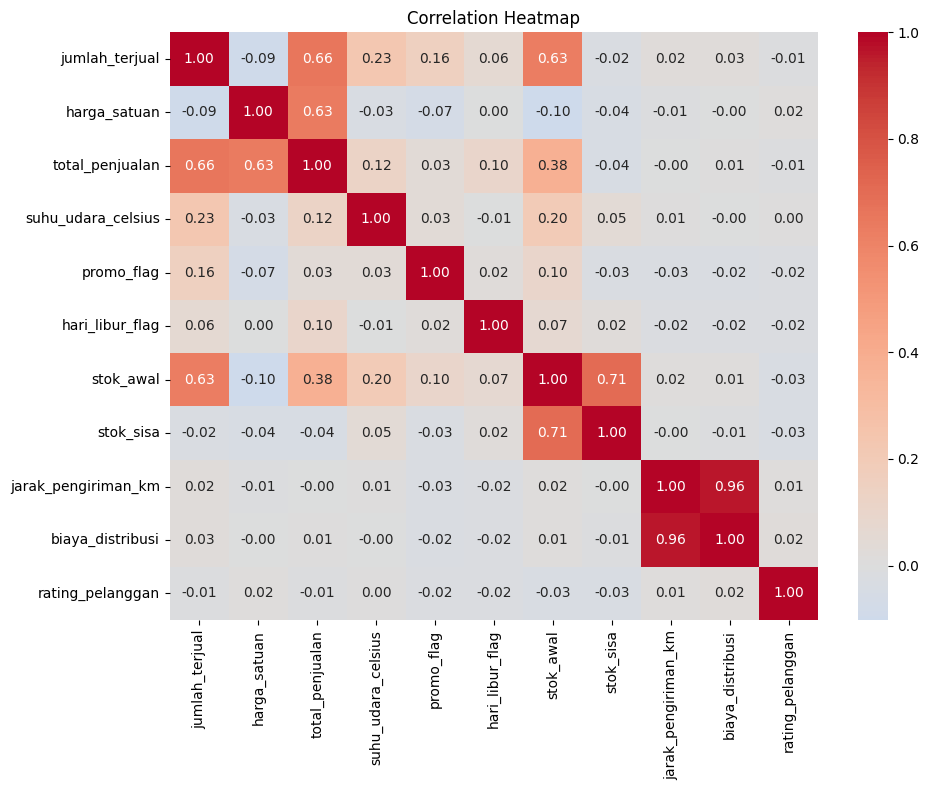

In [19]:
kolom_numerik = [
    'jumlah_terjual', 'harga_satuan', 'total_penjualan',
    'suhu_udara_celsius', 'promo_flag', 'hari_libur_flag',
    'stok_awal', 'stok_sisa', 'jarak_pengiriman_km',
    'biaya_distribusi', 'rating_pelanggan'
]

corr = df[kolom_numerik].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

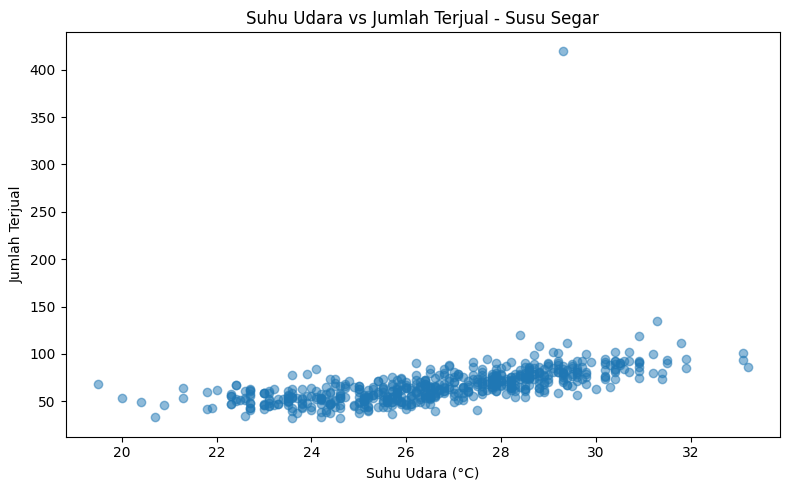

In [20]:
# Fokus ke Susu Segar: apakah suhu udara berhubungan dengan jumlah terjual?
susu_segar = df[df['produk'] == 'Susu Segar']

plt.figure(figsize=(8,5))
plt.scatter(susu_segar['suhu_udara_celsius'], susu_segar['jumlah_terjual'], alpha=0.5)
plt.title('Suhu Udara vs Jumlah Terjual - Susu Segar')
plt.xlabel('Suhu Udara (°C)')
plt.ylabel('Jumlah Terjual')
plt.tight_layout()
plt.show()

## 8. Model prediksi sederhana: Linear Regression

Di bagian ini kita membuat model sederhana untuk memprediksi jumlah penjualan **Susu Segar**.
Kita tidak mengejar model sempurna. Tujuannya adalah memahami ide dasar:

> komputer belajar pola dari data lama, lalu membuat prediksi untuk data baru.

In [21]:
# Ambil data Susu Segar saja
model_df = df[df['produk'] == 'Susu Segar'].copy()

# Fitur/input yang dipakai untuk prediksi
X = model_df[['suhu_udara_celsius', 'harga_satuan', 'promo_flag', 'hari_libur_flag']]

# Target/output yang ingin diprediksi
y = model_df['jumlah_terjual']

# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Buat dan latih model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediksi pada data uji
prediksi = model.predict(X_test)

print('MAE:', round(mean_absolute_error(y_test, prediksi), 2))
print('R2 Score:', round(r2_score(y_test, prediksi), 2))

MAE: 7.63
R2 Score: 0.64


In [22]:
# Contoh prediksi: hari panas, tidak promo, bukan hari libur
contoh_baru = pd.DataFrame({
    'suhu_udara_celsius': [31.0],
    'harga_satuan': [12000],
    'promo_flag': [0],
    'hari_libur_flag': [0]
})

hasil_prediksi = model.predict(contoh_baru)[0]
print(f"Prediksi penjualan Susu Segar: {hasil_prediksi:.0f} unit")

Prediksi penjualan Susu Segar: 86 unit


## 9. Anomaly detection: menemukan data yang aneh

Anomaly detection membantu kita menemukan data yang berbeda jauh dari biasanya.
Contoh: salah input, permintaan tiba-tiba melonjak, atau kejadian khusus.

In [23]:
# Hitung z-score untuk total_penjualan
# Z-score tinggi berarti data jauh dari rata-rata
rata = df['total_penjualan'].mean()
std = df['total_penjualan'].std()
df['z_score_penjualan'] = (df['total_penjualan'] - rata) / std

anomali = df[df['z_score_penjualan'].abs() > 3].sort_values('z_score_penjualan', ascending=False)

anomali[['tanggal', 'kecamatan', 'produk', 'jumlah_terjual', 'harga_satuan', 'total_penjualan', 'z_score_penjualan']].head(10)

,tanggal,kecamatan,produk,jumlah_terjual,harga_satuan,total_penjualan,z_score_penjualan
2101,2025-09-18,Ampel,Susu Segar,420,12000.0,5040000.0,14.305327
891,2024-11-02,Boyolali Kota,Keju Mozzarella,71,27655.0,1963505.0,4.541289
1450,2025-05-11,Mojosongo,Keju Mozzarella,64,28534.0,1826176.0,4.105441
1543,2025-06-14,Boyolali Kota,Keju Mozzarella,64,27728.0,1774592.0,3.941726
692,2024-08-25,Mojosongo,Keju Mozzarella,59,29358.0,1732122.0,3.806937
914,2024-11-10,Cepogo,Keju Mozzarella,66,26040.0,1718640.0,3.764148
2072,2025-12-20,Boyolali Kota,Keju Mozzarella,61,27941.0,1704401.0,3.718957
1303,2025-03-23,Mojosongo,Keju Mozzarella,65,26040.0,1692600.0,3.681504
1348,2025-04-06,Selo,Keju Mozzarella,57,29512.0,1682184.0,3.648446
1428,2025-05-03,Ampel,Keju Mozzarella,57,29146.0,1661322.0,3.582235


## 10. Kesimpulan laporan

Contoh cara menulis insight yang baik:

1. **Temuan:** Produk dengan penjualan terbesar adalah ...
2. **Bukti data:** Berdasarkan total penjualan, produk ini menghasilkan ...
3. **Makna bisnis:** Produk ini perlu dijaga stoknya, terutama pada ...
4. **Rekomendasi:** Pak Bambang sebaiknya ...

In [24]:
# Membuat ringkasan otomatis sederhana dari hasil analisis
produk_teratas = analisis_produk.index[0]
kecamatan_teratas = analisis_kecamatan.index[0]
bulan_teratas = tren_bulanan.sort_values('total_penjualan', ascending=False).iloc[0]['bulan']

print('RINGKASAN ANALISIS')
print('1. Produk dengan total penjualan tertinggi:', produk_teratas)
print('2. Kecamatan dengan total penjualan tertinggi:', kecamatan_teratas)
print('3. Bulan dengan total penjualan tertinggi:', bulan_teratas)
print('4. Jumlah data anomali yang perlu dicek:', len(anomali))

RINGKASAN ANALISIS
1. Produk dengan total penjualan tertinggi: Susu Segar
2. Kecamatan dengan total penjualan tertinggi: Cepogo
3. Bulan dengan total penjualan tertinggi: 2024-08
4. Jumlah data anomali yang perlu dicek: 21


## Rekomendasi untuk Pak Bambang

Silakan lengkapi bagian ini berdasarkan hasil analisis kalian:

1. Produk prioritas untuk dijaga stoknya adalah **...** karena **...**
2. Kecamatan yang paling potensial untuk ekspansi adalah **...** karena **...**
3. Promo paling efektif untuk jenis pelanggan **...**, sehingga strategi promo sebaiknya **...**
4. Data anomali pada tanggal **...** perlu dicek ulang karena **...**

## Cara export menjadi PDF
Di Google Colab: **File → Print → Save as PDF**.